In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load and Inspect Data

In [ ]:
# Loading data set using panda and display the first few rows with it's data type.

data = pd.read_csv('/content/drive/MyDrive/Python Project/Weather Data Analysis/weather_data.csv')

print(data.head())
print(data.dtypes)

         Date  Temperature_C  Humidity_pct  Precipitation_mm  Wind_Speed_kmh  \
0  2020-01-01           -0.5          65.2               2.1            10.4   
1  2020-01-02           -2.4          73.3               0.2            12.1   
2  2020-01-03           -0.1          68.2              16.3            14.2   
3  2020-01-04            2.6          70.4               5.5             NaN   
4  2020-01-05           -2.7          79.7               NaN            17.8   

  Condition  Season    Month  Year  
0     Snowy  Winter  January  2020  
1     Snowy  Winter  January  2020  
2     Rainy  Winter  January  2020  
3   Drizzle  Winter  January  2020  
4     Snowy  Winter  January  2020  
Date                 object
Temperature_C       float64
Humidity_pct        float64
Precipitation_mm    float64
Wind_Speed_kmh      float64
Condition            object
Season               object
Month                object
Year                  int64
dtype: object


# Data Cleaning

In [ ]:
#Handling missing values, conveting date columns to datetime format.

missing_count = data.isnull().sum()
data.fillna(data.mean(numeric_only=True), inplace=True)
print(missing_count)

data['Date'] = pd.to_datetime(data['Date'])
print(data.dtypes)


Date                 0
Temperature_C       43
Humidity_pct        43
Precipitation_mm    43
Wind_Speed_kmh      43
Condition            0
Season               0
Month                0
Year                 0
dtype: int64
Date                datetime64[ns]
Temperature_C              float64
Humidity_pct               float64
Precipitation_mm           float64
Wind_Speed_kmh             float64
Condition                   object
Season                      object
Month                       object
Year                         int64
dtype: object


# Descriptive Statistics with NumPy

In [ ]:
# Calculating Mean, Median, and Standard Deviation

for i in ['Temperature_C', 'Humidity_pct', 'Precipitation_mm']:
    print(f"{i} -> Mean: {np.mean(data[i]):.2f}, Median: {np.median(data[i]):.2f}, Std: {np.std(data[i]):.2f}")

Temperature_C -> Mean: 15.14, Median: 15.14, Std: 11.56
Humidity_pct -> Mean: 64.25, Median: 64.20, Std: 11.26
Precipitation_mm -> Mean: 5.65, Median: 3.80, Std: 6.88


# Monthly and Seasonal Analysis (using Pandas Group By)

In [ ]:
m_analysis = data.groupby('Month')[['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']].mean()
s_analysis = data.groupby('Season')[['Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']].mean()
print(s_analysis)
print(m_analysis)

        Temperature_C  Humidity_pct  Precipitation_mm  Wind_Speed_kmh
Season                                                               
Autumn      16.152084     67.245629          6.435713       14.783221
Spring      14.744071     61.371648          6.731144       14.817428
Summer      28.925537     54.170025          4.101170       14.662872
Winter       0.469637     74.445067          5.349925       14.694059
           Temperature_C  Humidity_pct  Precipitation_mm  Wind_Speed_kmh
Month                                                                   
April          15.022995     60.247096          7.295127       14.227654
August         29.607252     54.325072          4.429528       14.387246
December        1.601934     75.783943          6.711290       14.571117
February        1.828844     71.707588          3.827025       14.722473
January        -1.901292     75.600830          5.376363       14.791109
July           30.342899     52.185923          3.917865       14.469

# Visualization with Matplotlib

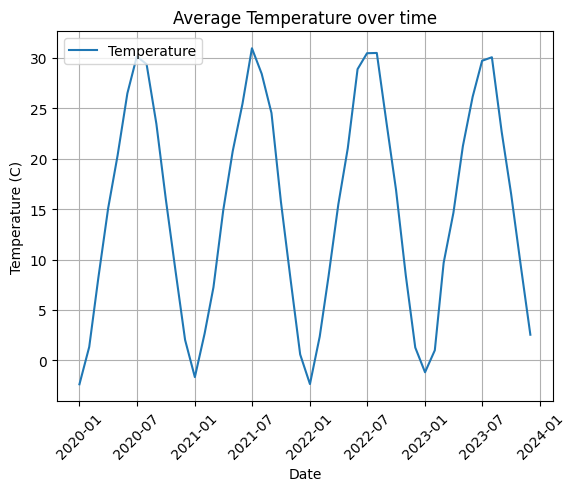

In [ ]:
# Average temperature trends over time(monthly/yearly)
monthly_temp = data.groupby(data['Date'].dt.to_period('M'))['Temperature_C'].mean()
monthly_temp.index = monthly_temp.index.to_timestamp()

plt.plot(monthly_temp.index, monthly_temp.values, label='Temperature')
plt.title('Average Temperature over time')
plt.xlabel('Date')
plt.ylabel('Temperature (C)')
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()


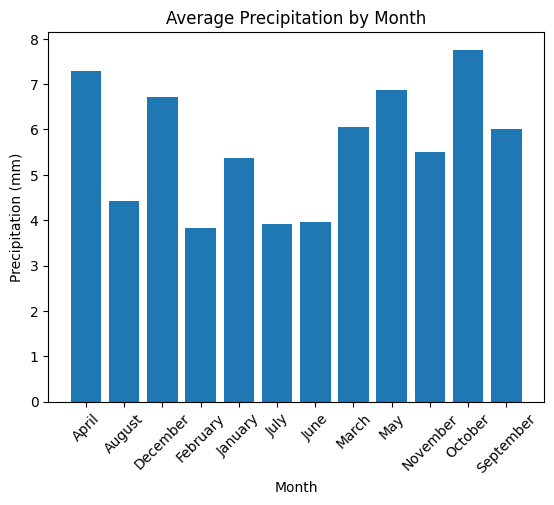

In [ ]:
# Total or Average precipitation by month
monthly_precip = data.groupby('Month')['Precipitation_mm'].mean()

plt.bar(monthly_precip.index, monthly_precip.values)
plt.title('Average Precipitation by Month')
plt.xlabel('Month')
plt.ylabel('Precipitation (mm)')
plt.xticks(rotation=45)
plt.show()

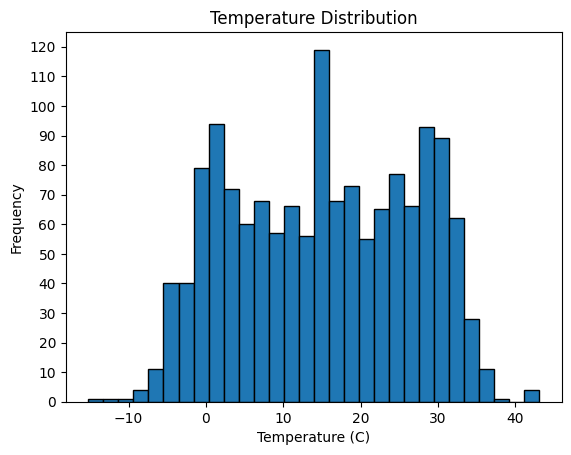

In [ ]:
# Temperature Distribution
plt.hist(data['Temperature_C'], edgecolor='black', bins=30)
plt.title('Temperature Distribution')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')
plt.yticks(range(0,130,10))
plt.show()

# Identify Extreme Weather

In [ ]:
# Use NumPy to filter days with exteme temperature

High_Temperature = 40
Low_Temperature = -5
extreme = data[(data['Temperature_C'] > High_Temperature) | (data['Temperature_C'] < Low_Temperature)]

print(extreme[['Date', 'Temperature_C']])

           Date  Temperature_C
10   2020-01-11          -15.2
13   2020-01-14           -7.7
14   2020-01-15           -7.2
19   2020-01-20           -6.2
23   2020-01-24           -6.3
26   2020-01-27           -5.5
199  2020-07-18          -12.8
209  2020-07-28           42.6
354  2020-12-20           41.9
382  2021-01-17           -8.4
392  2021-01-27           -6.0
396  2021-01-31           -7.1
708  2021-12-09           -5.2
733  2022-01-03           -7.1
740  2022-01-10           -7.5
741  2022-01-11           -5.8
749  2022-01-19           -6.2
751  2022-01-21           -6.1
886  2022-06-05           42.5
1097 2023-01-02           -8.0
1101 2023-01-06          -10.7
1105 2023-01-10           -5.1
1107 2023-01-12           -5.2
1123 2023-01-28           -5.4
1125 2023-01-30           -5.4
1151 2023-02-25           -5.5
1163 2023-03-09           43.1
